Note: Each block of code cell is explained with its results under it. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score


In [2]:
# Display settings — show more columns/rows when inspecting
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# The dataset uses semicolons as separators, not commas (it's European-style CSV)
df = pd.read_csv("../data/bank-additional-full.csv", sep=";")

print(f"Shape: {df.shape}")
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


What the shape tells us: 
There are 41,188 rows, and each row represents a single phone call the Portuguese bank placed to one customer during their telemarketing campaigns between 2008 and 2013. Twenty-one columns means each of those calls has 21 pieces of information: 20 features (things known before or during the call) and one target (whether the customer eventually subscribed to the term deposit).

What the columns tell us: 
Looking at the head output, the 21 columns split into three logical groupings:
1. what the bank knows about the customer: their age, their job (occupation — admin, services, housemaid, technician, and so on), marital status, education level, whether they have ever defaulted on credit, whether they currently have a housing loan, and whether they have a personal loan. These are stable demographic and financial facts about the person being called.
2. information about the call itself and the campaign context: contact is the channel used (cellular or telephone, meaning landline); month is the calendar month of the last contact; day_of_week is the day; duration is how long the call lasted in seconds; campaign is how many times the bank has already called this person during the current campaign; pdays records days since the last contact from a previous campaign; previous counts how many times they were contacted before this campaign began; and poutcome is the result of that previous campaign — "success," "failure," or "nonexistent" if there wasn't a previous campaign at all.
3. macroeconomic snapshot at the time of the call: emp.var.rate (employment variation rate, a quarterly figure showing how Portuguese employment is changing), cons.price.idx (consumer price index, a monthly inflation indicator), cons.conf.idx (consumer confidence index, also monthly), euribor3m (the three-month Euribor — the rate at which European banks lend to each other in euros, updated daily), and nr.employed (a quarterly figure tracking total employment levels).

The final column, y, is the target: did this customer eventually subscribe to a term deposit?

In [3]:
# Column types and any obvious nulls
df.info()

print("\n--- Target distribution ---")
print(df["y"].value_counts())
print(f"\nPositive rate: {(df['y'] == 'yes').mean():.2%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

There are no missing values in this dataset.But watch out. That conclusion would be wrong. Missing data here isn't represented by NaN or null. It's encoded as the string 'unknown' in the categorical columns and as the integer 999 in the numeric pdays column. 

The counts 36,548 no / 4,640 yes confirm the brief's "~11% positive" exactly: 11.27%. About one customer in nine actually subscribes to the term deposit; the other eight decline. The imbalance ratio is roughly 8.85 to 1.

In [4]:
# Trap 1: duration leaks the target — calls that result in "yes" tend to be longer
print("Avg duration by target:")
print(df.groupby("y")["duration"].agg(["mean", "median"]))

# Trap 2: pdays == 999 is a sentinel for "never contacted before"
print("\npdays distribution:")
print(f"  Rows with pdays == 999: {(df['pdays'] == 999).sum()} ({(df['pdays'] == 999).mean():.2%})")
print(f"  Rows with real day counts: {(df['pdays'] != 999).sum()}")
print(f"  Range of real values: {df.loc[df['pdays'] != 999, 'pdays'].min()} – {df.loc[df['pdays'] != 999, 'pdays'].max()}")

# Trap 3: 'unknown' is informative, not missing — count occurrences across all categorical columns
print("\n'unknown' counts per column:")
for col in df.select_dtypes(include="object").columns:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        print(f"  {col}: {n_unknown} ({n_unknown / len(df):.2%})")

Avg duration by target:
           mean  median
y                      
no   220.844807   163.5
yes  553.191164   449.0

pdays distribution:
  Rows with pdays == 999: 39673 (96.32%)
  Rows with real day counts: 1515
  Range of real values: 0 – 27

'unknown' counts per column:
  job: 330 (0.80%)
  marital: 80 (0.19%)
  education: 1731 (4.20%)
  default: 8597 (20.87%)
  housing: 990 (2.40%)
  loan: 990 (2.40%)


Calls that ended in "no" lasted an average of 221 seconds, with a median of 164 seconds. Calls that ended in "yes" lasted an average of 553 seconds, with a median of 449 seconds. Successful calls are roughly two-and-a-half times longer than unsuccessful ones.The duration of a call does not cause a customer to subscribe. The relationship runs the other way: customers who are going to subscribe end up on longer calls because, having said yes, the agent then walks them through the signup paperwork — collecting their personal information, explaining the terms, processing the agreement. The duration is partly a consequence of the outcome, not a predictor of it. But a model cannot tell the difference between cause and correlation; it just sees the correlation, and the correlation between duration and y is enormous. We have to drop it. 

the overwhelming majority of customers have never been contacted in any previous campaign. Only 1,515 rows — 3.68% of the dataset — carry real day counts, and those real values range from 0 to 27. So when there was a previous contact, it happened within the last month or so.

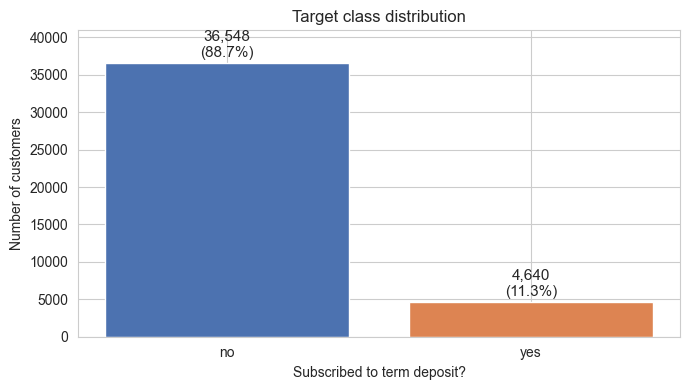

With a 60/20/20 split, training set will contain roughly
2,784 actual subscribers.
These are the positive examples the model has to learn from.


In [5]:
# Set a clean default style for all our EDA plots in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# ────────────────────────────────────────────────────────────────────
# Plot — Target class distribution.
# We want to see the imbalance visually, with both raw counts and
# percentage labels, so the disparity is impossible to miss.
# ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

target_counts = df["y"].value_counts()
colors = ["#4C72B0", "#DD8452"]  # muted blue for "no", warm orange for "yes"

bars = ax.bar(target_counts.index, target_counts.values, color=colors)
ax.set_title("Target class distribution")
ax.set_xlabel("Subscribed to term deposit?")
ax.set_ylabel("Number of customers")

# Annotate each bar with its count and percentage of total
total = target_counts.sum()
for bar, count in zip(bars, target_counts.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11,
    )

# Give the plot a little headroom above the tallest bar so labels don't get clipped
ax.set_ylim(0, target_counts.max() * 1.12)

plt.tight_layout()
plt.show()

# A practical implication of the imbalance, stated in concrete numbers
n_positive_total = (df["y"] == "yes").sum()
print(f"With a 60/20/20 split, training set will contain roughly")
print(f"{int(0.6 * n_positive_total):,} actual subscribers.")
print(f"These are the positive examples the model has to learn from.")

The class imbalance makes accuracy degenerate; a constant 'no' predictor would score 88.7%.

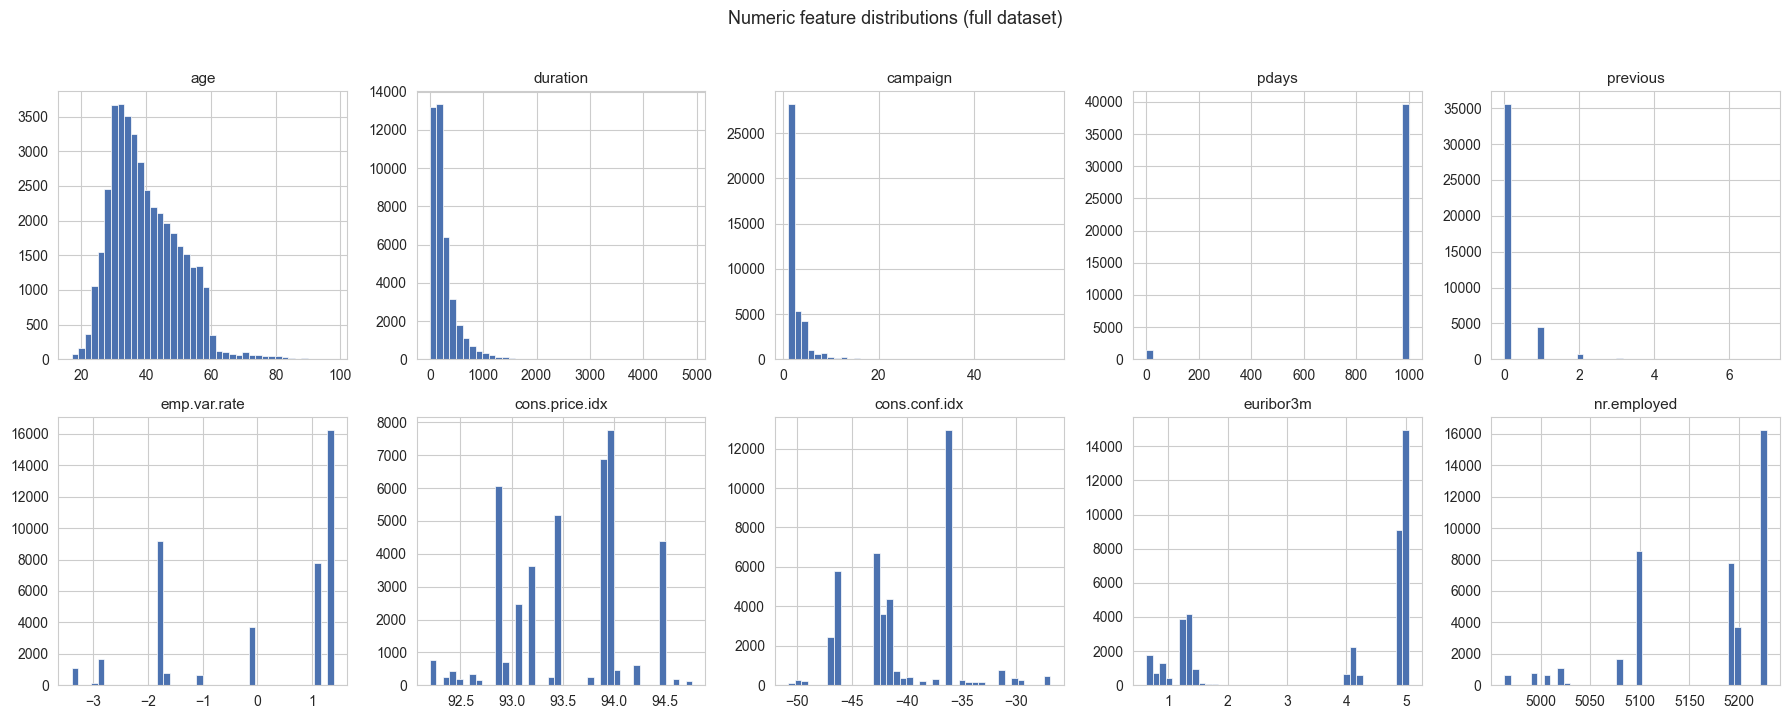

In [6]:
# All 10 numeric columns currently in the dataframe (before any cleaning)
numeric_features = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed",
]

# 2 rows × 5 columns of subplots — wide enough to see them all clearly
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()  # makes it easier to iterate over all 10 axes in one loop

for ax, col in zip(axes, numeric_features):
    # 40 bins gives enough resolution to see structure without being noisy
    ax.hist(df[col], bins=40, color="#4C72B0", edgecolor="white", linewidth=0.5)
    ax.set_title(col, fontsize=11)
    # Drop default labels — the title alone is enough at this density
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Numeric feature distributions (full dataset)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**AGE**:
* Age distribution is **right-skewed**, peaking around **31–33**, with a long tail into older ages and almost no values past 90.
* This feature is **clean and well-behaved**: no missing values, outliers, or encoding issues, making it easy for models to use.
* The dataset contains **more younger customers**, even though they are **less likely to subscribe**.
* This reflects **sampling bias** (who the bank contacted), not actual likelihood of subscription across ages.
**Duration, Campaign, Previous**:
* All three count features (**duration, campaign, previous**) are **heavily right-skewed**: most values are near zero with long tails.
* Typical patterns: **short calls**, **few contacts per campaign**, and **no prior contacts** for most customers.
* The **long tails contain signal**: e.g., campaign values up to ~50 suggest repeated attempts on difficult or high-potential customers.
* The **previous feature is almost binary** (mostly 0), reinforcing that most customers were **contacted for the first time**.
* **previous and pdays are highly correlated**, both indicating prior contact history.
* Converting **pdays into a flag + numeric feature** preserves information, since it overlaps strongly with previous.
**pdays**:
* The **pdays feature is effectively binary**, not continuous:

  * A small group (≈1,500 rows) with values **0–27 days**
  * A massive group (≈40,000 rows) at **999 = never contacted**
* Treating it as numeric is misleading; it’s a **binary signal disguised as a number**.
* Using it directly with scaling would **distort the data**, making real values appear as outliers and reducing usefulness.
* Best approach: **split into two features**:

  * A **flag** (was contacted before or not)
  * A **numeric column** (days since contact, only when applicable)
* This transformation makes both features **clean, interpretable, and model-friendly**, allowing the model to learn distinct patterns for new vs. previously contacted customers.
* The macroeconomic features reveal **clear regime shifts**, not random variation.
* **euribor3m is bimodal** (~1–1.5 vs. ~5.0), reflecting **pre- and post-2008 financial crisis interest-rate regimes** with little transition between them.
* Other features show the same pattern:

  * **emp.var.rate** splits into positive (pre-crisis) and negative (recession) clusters
  * **nr.employed** changes in **step-like drops** due to quarterly reporting during the downturn
  * **cons.price.idx** and **cons.conf.idx** appear smoother but still reflect regime changes
* These patterns make the dataset ideal for **drift demonstrations**:

  * Shifting features like **euribor3m** or **cons.price.idx** simulates realistic economic changes
  * Such shifts **redistribute data across bins**, causing **PSI spikes**
* Key narrative: the model is trained mostly on one regime (post-crisis), and simulated shifts mimic **unseen economic conditions**, enabling clear drift detection and investigation.
* Macroeconomic features have **very low cardinality** (≈5–15 distinct values), each repeated many times.
* Their histograms therefore have **few effective bins**, with most probability mass concentrated in a small number of them.
* Even **small distribution shifts** (e.g., more data from a different month) can **move mass between bins**, producing **large PSI changes**.
* This makes these features **highly sensitive to drift**, which is useful but can lead to **over-triggering alerts**.
* Alert thresholds should be **carefully calibrated** to avoid reacting to minor, expected fluctuations.



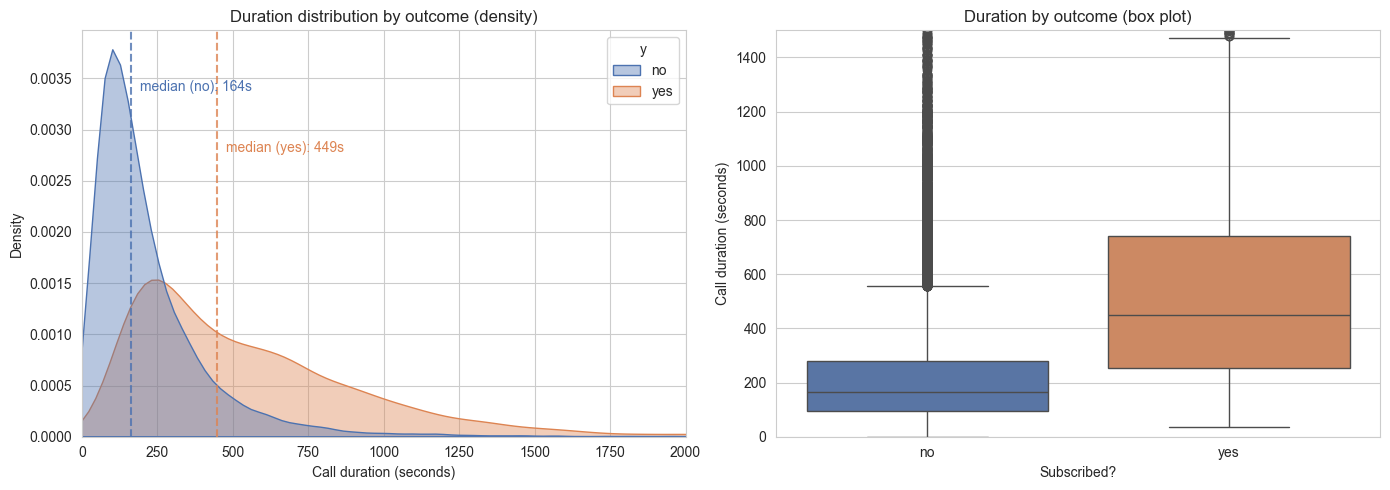

In [7]:

# 1 row × 2 columns — the same data shown two complementary ways
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ────────────────────────────────────────────────────────────────────
# Left panel — KDE overlay
# Each class's distribution is normalized independently (common_norm=False)
# so we can compare shapes regardless of the 8.85:1 size imbalance.
# ────────────────────────────────────────────────────────────────────
palette = {"no": "#4C72B0", "yes": "#DD8452"}

sns.kdeplot(
    data=df,
    x="duration",
    hue="y",
    fill=True,
    alpha=0.4,
    common_norm=False,   # normalize each class to area=1 separately
    palette=palette,
    ax=axes[0],
)

# Crop the x-axis at 2000s — the tail goes to ~5000 but virtually no mass lives there
axes[0].set_xlim(0, 2000)
axes[0].set_title("Duration distribution by outcome (density)")
axes[0].set_xlabel("Call duration (seconds)")

# Annotate the medians directly on the plot — this is the one number reviewers will quote
median_no  = df.loc[df["y"] == "no",  "duration"].median()
median_yes = df.loc[df["y"] == "yes", "duration"].median()

axes[0].axvline(median_no,  color="#4C72B0", linestyle="--", alpha=0.8)
axes[0].axvline(median_yes, color="#DD8452", linestyle="--", alpha=0.8)

# Move the legend into a corner that won't overlap the curves
axes[0].text(median_no  + 30, axes[0].get_ylim()[1] * 0.85,
             f"median (no): {median_no:.0f}s", color="#4C72B0")
axes[0].text(median_yes + 30, axes[0].get_ylim()[1] * 0.70,
             f"median (yes): {median_yes:.0f}s", color="#DD8452")

# ────────────────────────────────────────────────────────────────────
# Right panel — box plot
# Shows the same comparison in summary form: medians, quartiles,
# and whiskers, with the size difference visualized via box width.
# ────────────────────────────────────────────────────────────────────
sns.boxplot(
    data=df,
    x="y",
    y="duration",
    hue="y",
    palette=palette,
    legend=False,
    ax=axes[1],
)

axes[1].set_ylim(0, 1500)  # crop extreme outliers so the boxes are readable
axes[1].set_title("Duration by outcome (box plot)")
axes[1].set_xlabel("Subscribed?")
axes[1].set_ylabel("Call duration (seconds)")

plt.tight_layout()
plt.show()

Most features (age, job, contact info, macro variables, previous campaign data) are known before prediction → safe
duration is only known after the call ends → fails timing test → leaks outcome

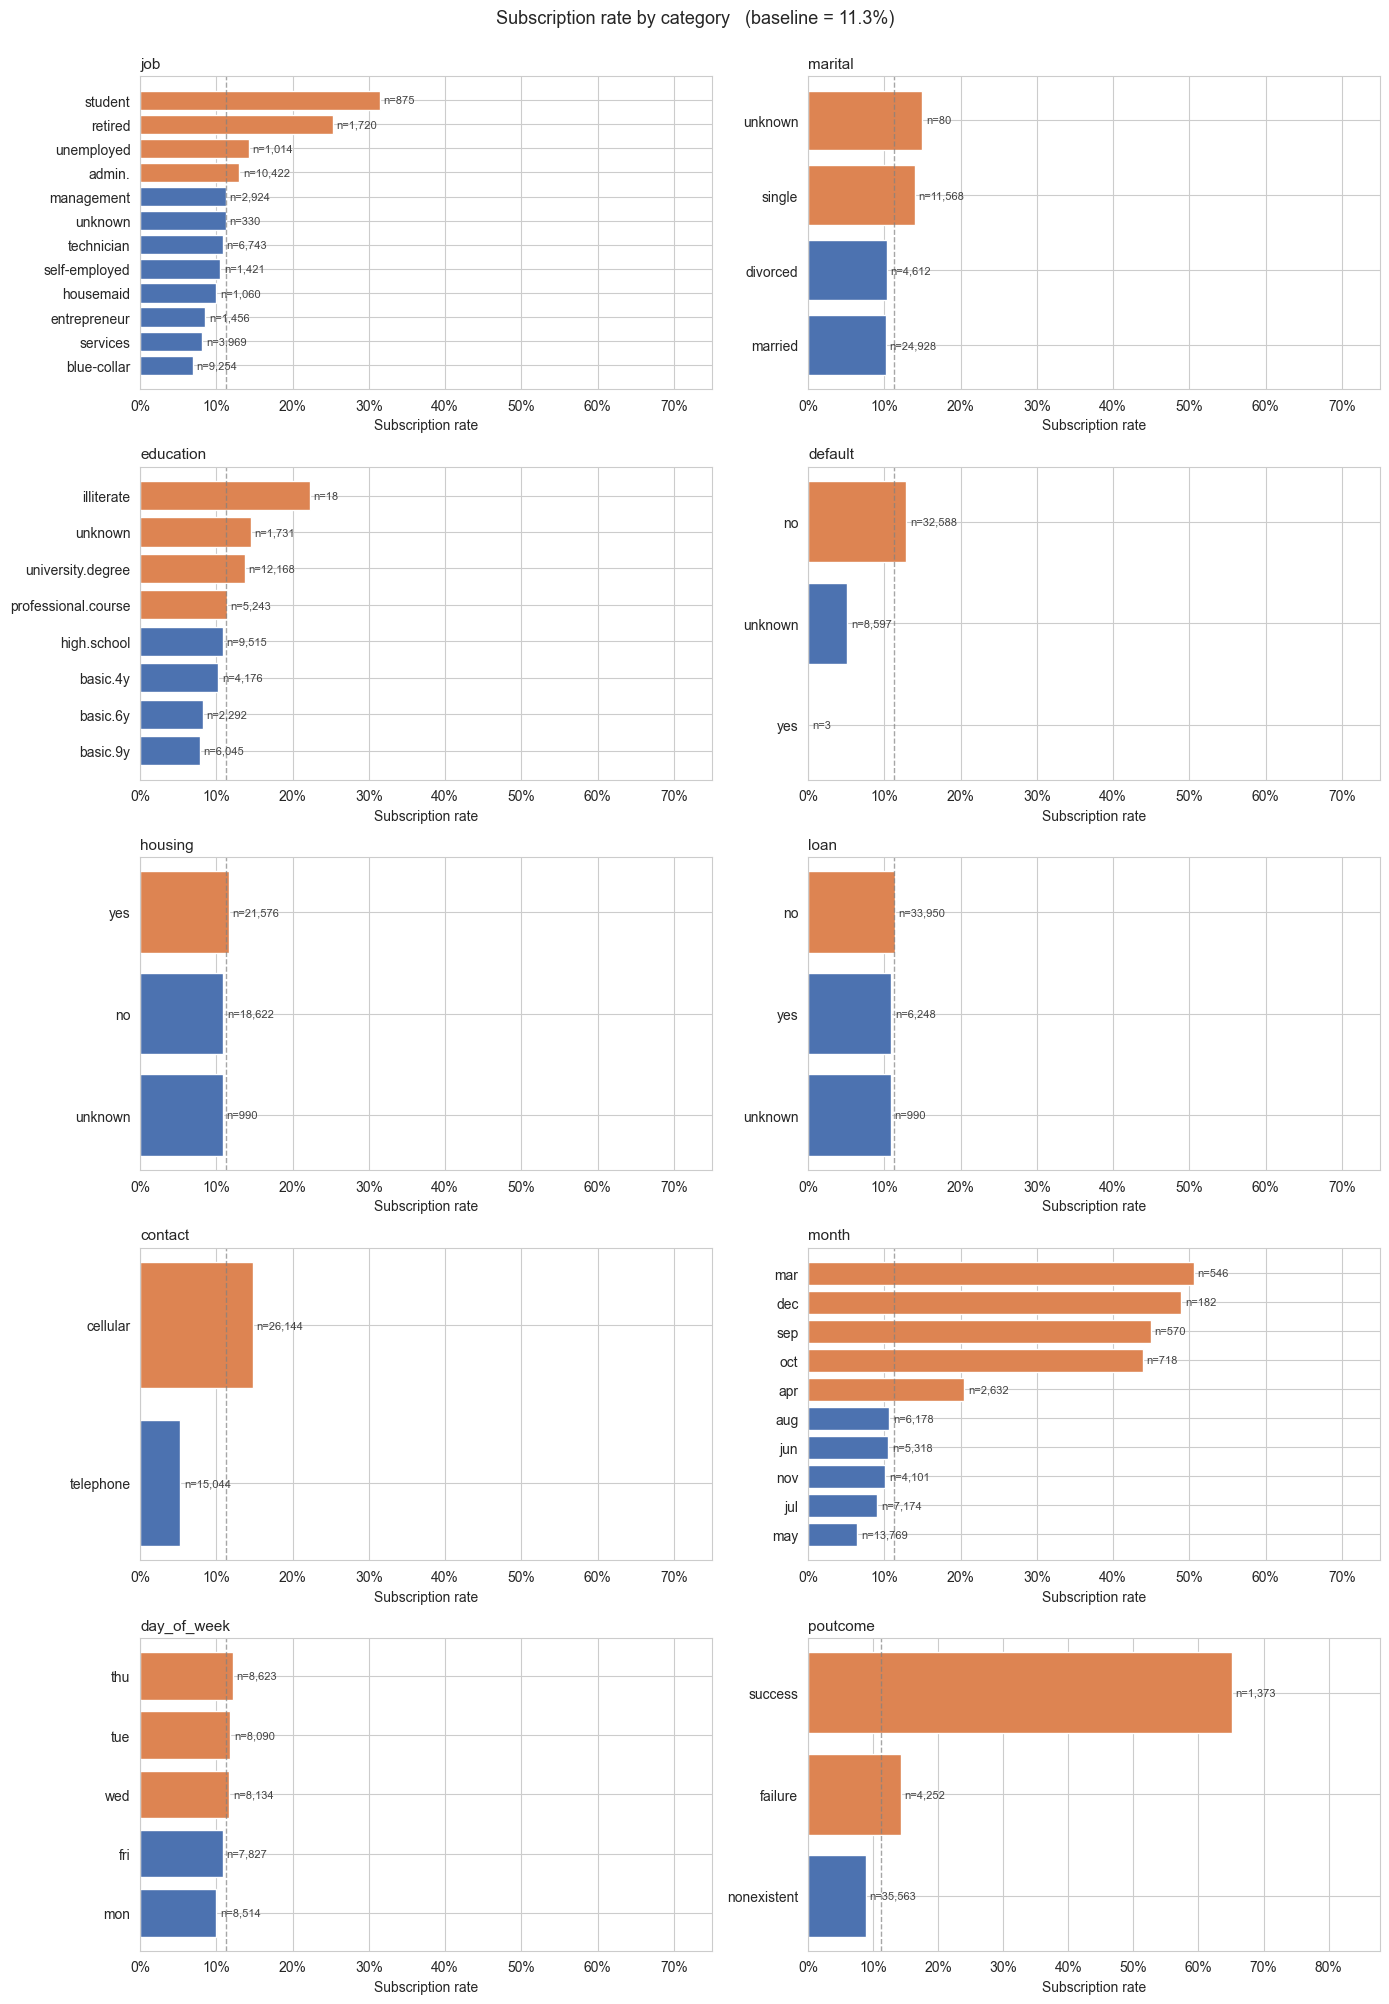

In [8]:
categorical_cols = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome",
]

# Overall positive rate — the "if I knew nothing" baseline
baseline = (df["y"] == "yes").mean()

# 5 rows × 2 columns gives each plot enough horizontal room for category labels
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    # For each category, compute the subscription rate AND the row count.
    # The rate tells us "how predictive is this category"; the count tells
    # us "is the rate trustworthy or based on a tiny sample?"
    grouped = (
        df.groupby(col)["y"]
          .agg(rate=lambda x: (x == "yes").mean(), count="count")
          .sort_values("rate", ascending=True)
    )

    # Color bars by whether they're above or below baseline.
    # Orange (above) = positive predictor of subscription.
    # Blue (below)  = negative predictor.
    colors = ["#DD8452" if r > baseline else "#4C72B0" for r in grouped["rate"]]

    bars = ax.barh(grouped.index, grouped["rate"], color=colors, edgecolor="white")

    # Reference line at the overall positive rate
    ax.axvline(baseline, color="gray", linestyle="--", alpha=0.7, linewidth=1)

    # Annotate every bar with its sample size — a category with high rate
    # but only n=10 samples is a fluke, not a real signal
    x_max = max(grouped["rate"].max() * 1.35, 0.75)
    for bar, count in zip(bars, grouped["count"]):
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"n={count:,}",
            va="center",
            fontsize=8,
            color="#444",
        )

    ax.set_title(col, fontsize=11, loc="left")
    ax.set_xlabel("Subscription rate")
    ax.set_xlim(0, x_max)
    # Format x-axis as percentages for readability
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.suptitle(
    f"Subscription rate by category   (baseline = {baseline:.1%})",
    fontsize=13,
    y=1.00,
)
plt.tight_layout()
plt.show()

In [9]:
# Drop the leakage column.
df = df.drop(columns=["duration"])

# Split pdays into a flag + a clean numeric.
df["was_contacted_before"] = (df["pdays"] != 999).astype(int)
df["days_since_contact"]   = df["pdays"].where(df["pdays"] != 999, other=0)
df = df.drop(columns=["pdays"])

# Encode the target as 0/1.
df["y"] = df["y"].map({"no": 0, "yes": 1})

# Verify
print(f"Shape after cleaning: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print()
print("Target encoding:")
print(df["y"].value_counts().sort_index())
print()
print(f"was_contacted_before counts: {df['was_contacted_before'].value_counts().sort_index().to_dict()}")
print(f"days_since_contact range: {df['days_since_contact'].min()} – {df['days_since_contact'].max()}")

Shape after cleaning: (41188, 21)
Columns (21): ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'days_since_contact']

Target encoding:
y
0    36548
1     4640
Name: count, dtype: int64

was_contacted_before counts: {0: 39673, 1: 1515}
days_since_contact range: 0 – 27


In [10]:


numeric_cols = [
    "age", "campaign", "previous",
    "was_contacted_before", "days_since_contact",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed",
]
categorical_cols = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome",
]

assert set(numeric_cols + categorical_cols + ["y"]) == set(df.columns), \
    "Column lists do not partition the dataframe — investigate."

X = df.drop(columns=["y"])
y = df["y"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42,
)

print(f"Train: {len(X_train):>6,} rows  |  positive rate: {y_train.mean():.2%}")
print(f"Val:   {len(X_val):>6,} rows  |  positive rate: {y_val.mean():.2%}")
print(f"Test:  {len(X_test):>6,} rows  |  positive rate: {y_test.mean():.2%}")
print(f"Total: {len(X_train) + len(X_val) + len(X_test):>6,} rows")

rates = [y_train.mean(), y_val.mean(), y_test.mean()]
assert max(rates) - min(rates) < 0.001, f"Stratification broken: {rates}"

Train: 24,712 rows  |  positive rate: 11.27%
Val:    8,238 rows  |  positive rate: 11.26%
Test:   8,238 rows  |  positive rate: 11.26%
Total: 41,188 rows


In [11]:


preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

candidates = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42, n_jobs=-1,
    ),
    "GradientBoosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=42,
    ),
}

results = {}
for name, model in candidates.items():
    pipe = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("classifier", model),
    ])
    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:, 1]
    auc_val   = roc_auc_score(y_val, proba_val)

    sweep      = np.linspace(0.01, 0.99, 99)
    rec_sweep  = np.array([recall_score(y_val,    proba_val >= t)               for t in sweep])
    prec_sweep = np.array([precision_score(y_val, proba_val >= t, zero_division=0) for t in sweep])
    f1_sweep   = np.array([f1_score(y_val,        proba_val >= t, zero_division=0) for t in sweep])

    valid = rec_sweep >= 0.75
    if valid.any():
        chosen_t = sweep[valid].max()
        idx = np.where(sweep == chosen_t)[0][0]
        results[name] = {
            "pipeline": pipe, "auc": auc_val,
            "threshold": chosen_t,
            "recall":    rec_sweep[idx],
            "precision": prec_sweep[idx],
            "f1":        f1_sweep[idx],
            "proba_val": proba_val,
            "sweep":     sweep,
            "rec_sweep": rec_sweep,
            "prec_sweep": prec_sweep,
            "f1_sweep":  f1_sweep,
        }
    else:
        results[name] = {"pipeline": pipe, "auc": auc_val, "threshold": None}

print(f"{'Model':<22} {'AUC':>7}  {'Thresh':>7}  {'Recall':>7}  {'Prec':>7}  {'F1':>6}")
print("-" * 64)
for name, r in results.items():
    if r.get("threshold") is not None:
        print(f"{name:<22} {r['auc']:>7.4f}  {r['threshold']:>7.3f}  "
              f"{r['recall']:>7.3f}  {r['precision']:>7.3f}  {r['f1']:>6.3f}")
    else:
        print(f"{name:<22} {r['auc']:>7.4f}  {'—':>7}  {'—':>7}  {'—':>7}  {'—':>6}")

Model                      AUC   Thresh   Recall     Prec      F1
----------------------------------------------------------------
LogisticRegression      0.7970    0.360    0.763    0.222   0.344
RandomForest            0.7756    0.050    0.789    0.192   0.309
GradientBoosting        0.8057    0.340    0.764    0.221   0.342


In [12]:
from sklearn.calibration import CalibratedClassifierCV

# cv=10 fits each base model 10 times.
calibrated_results = {}

for name, model in candidates.items():
    pipe = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("classifier", CalibratedClassifierCV(
            clone(model),
            method="sigmoid",  # Platt scaling — stable for all three model types
            cv=10,
        )),
    ])
    pipe.fit(X_train, y_train)

    proba_val = pipe.predict_proba(X_val)[:, 1]
    auc_val   = roc_auc_score(y_val, proba_val)

    sweep      = np.linspace(0.01, 0.99, 99)
    rec_sweep  = np.array([recall_score(y_val,    proba_val >= t)               for t in sweep])
    prec_sweep = np.array([precision_score(y_val, proba_val >= t, zero_division=0) for t in sweep])
    f1_sweep   = np.array([f1_score(y_val,        proba_val >= t, zero_division=0) for t in sweep])

    valid = rec_sweep >= 0.75
    if valid.any():
        chosen_t = sweep[valid].max()
        idx = np.where(sweep == chosen_t)[0][0]
        calibrated_results[name] = {
            "pipeline":  pipe,
            "auc":       auc_val,
            "threshold": chosen_t,
            "recall":    rec_sweep[idx],
            "precision": prec_sweep[idx],
            "f1":        f1_sweep[idx],
            "proba_val": proba_val,
            "sweep":     sweep,
            "rec_sweep": rec_sweep,
            "prec_sweep": prec_sweep,
            "f1_sweep":  f1_sweep,
        }
    else:
        calibrated_results[name] = {"pipeline": pipe, "auc": auc_val, "threshold": None}

# Side-by-side: raw vs calibrated for each model
print(f"{'Model':<22} {'Ver':>5}  {'AUC':>7}  {'Thresh':>7}  {'Recall':>7}  {'Prec':>7}  {'F1':>6}")
print("-" * 72)
for name in candidates:
    for label, res in [("raw", results), ("cal", calibrated_results)]:
        r = res[name]
        if r.get("threshold") is not None:
            print(f"{name:<22} {label:>5}  {r['auc']:>7.4f}  {r['threshold']:>7.3f}  "
                  f"{r['recall']:>7.3f}  {r['precision']:>7.3f}  {r['f1']:>6.3f}")
        else:
            print(f"{name:<22} {label:>5}  {r['auc']:>7.4f}  {'—':>7}  {'—':>7}  {'—':>7}  {'—':>6}")
    print()

Model                    Ver      AUC   Thresh   Recall     Prec      F1
------------------------------------------------------------------------
LogisticRegression       raw   0.7970    0.360    0.763    0.222   0.344
LogisticRegression       cal   0.7971    0.060    0.816    0.186   0.303

RandomForest             raw   0.7756    0.050    0.789    0.192   0.309
RandomForest             cal   0.7821    0.060    0.830    0.171   0.283

GradientBoosting         raw   0.8057    0.340    0.764    0.221   0.342
GradientBoosting         cal   0.8051    0.070    0.756    0.232   0.355



In [13]:
# Cross-validated AUC variance check — tells us whether the AUC differences
# above are real or sampling noise, and whether calibration genuinely helps
# each model or just reshuffles probabilities.
# Outer CV: 10-fold stratified. Inner calibration CV: 5-fold to avoid
# 10×10 nesting blowing up runtime on RandomForest.

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

model_variants = {}
for name, model in candidates.items():
    model_variants[f"{name} (raw)"] = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("classifier", clone(model)),
    ])
    model_variants[f"{name} (calibrated)"] = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("classifier", CalibratedClassifierCV(clone(model), method="sigmoid", cv=5)),
    ])

print(f"{'Model':<35}  {'AUC mean':>9}  {'AUC std':>8}  {'min':>7}  {'max':>7}")
print("-" * 75)

cv_results = {}
for name, pipe in model_variants.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results[name] = scores
    print(f"{name:<35}  {scores.mean():>9.4f}  {scores.std():>8.4f}  "
          f"{scores.min():>7.4f}  {scores.max():>7.4f}")

# Raw vs calibrated — paired per-fold comparison for each model
print()
print("Raw vs calibrated — per-fold paired comparison (same 10 folds):")
print()
for name in candidates:
    raw_scores = cv_results[f"{name} (raw)"]
    cal_scores = cv_results[f"{name} (calibrated)"]
    diff = cal_scores - raw_scores
    wins_cal = (diff > 0).sum()
    print(f"  {name}")
    print(f"    Calibrated wins {wins_cal}/10 folds  |  mean gap {diff.mean():+.4f} ± {diff.std():.4f}")
    print()

# Pairwise model comparison (raw) — is the gap between models real?
print("Raw model pairwise comparison (same 10 folds):")
print()
names = list(candidates.keys())
for i, a in enumerate(names):
    for b in names[i + 1:]:
        diff = cv_results[f"{a} (raw)"] - cv_results[f"{b} (raw)"]
        wins_a = (diff > 0).sum()
        print(f"  {a} vs {b}")
        print(f"    {a} wins {wins_a}/10 folds  |  mean gap {diff.mean():+.4f} ± {diff.std():.4f}")
        print()

Model                                 AUC mean   AUC std      min      max
---------------------------------------------------------------------------
LogisticRegression (raw)                0.7869    0.0179   0.7529   0.8126
LogisticRegression (calibrated)         0.7869    0.0179   0.7529   0.8125
RandomForest (raw)                      0.7706    0.0156   0.7484   0.7908
RandomForest (calibrated)               0.7742    0.0170   0.7454   0.7951
GradientBoosting (raw)                  0.7911    0.0175   0.7683   0.8195
GradientBoosting (calibrated)           0.7950    0.0148   0.7752   0.8165

Raw vs calibrated — per-fold paired comparison (same 10 folds):

  LogisticRegression
    Calibrated wins 6/10 folds  |  mean gap +0.0000 ± 0.0001

  RandomForest
    Calibrated wins 8/10 folds  |  mean gap +0.0036 ± 0.0032

  GradientBoosting
    Calibrated wins 7/10 folds  |  mean gap +0.0039 ± 0.0037

Raw model pairwise comparison (same 10 folds):

  LogisticRegression vs RandomForest
    Log

In [14]:
WINNER         = "GradientBoosting"
USE_CALIBRATED = False

chosen_results   = calibrated_results if USE_CALIBRATED else results
pipeline         = chosen_results[WINNER]["pipeline"]
chosen_threshold = chosen_results[WINNER]["threshold"]

print(f"Winner: {WINNER}  ({'calibrated' if USE_CALIBRATED else 'raw'})")
print(f"  Validation AUC:       {chosen_results[WINNER]['auc']:.4f}")
print(f"  Operating threshold:  {chosen_threshold:.3f}")
print(f"  Validation recall:    {chosen_results[WINNER]['recall']:.4f}")
print(f"  Validation precision: {chosen_results[WINNER]['precision']:.4f}")
print(f"  Validation F1:        {chosen_results[WINNER]['f1']:.4f}")

Winner: GradientBoosting  (raw)
  Validation AUC:       0.8057
  Operating threshold:  0.340
  Validation recall:    0.7640
  Validation precision: 0.2206
  Validation F1:        0.3423


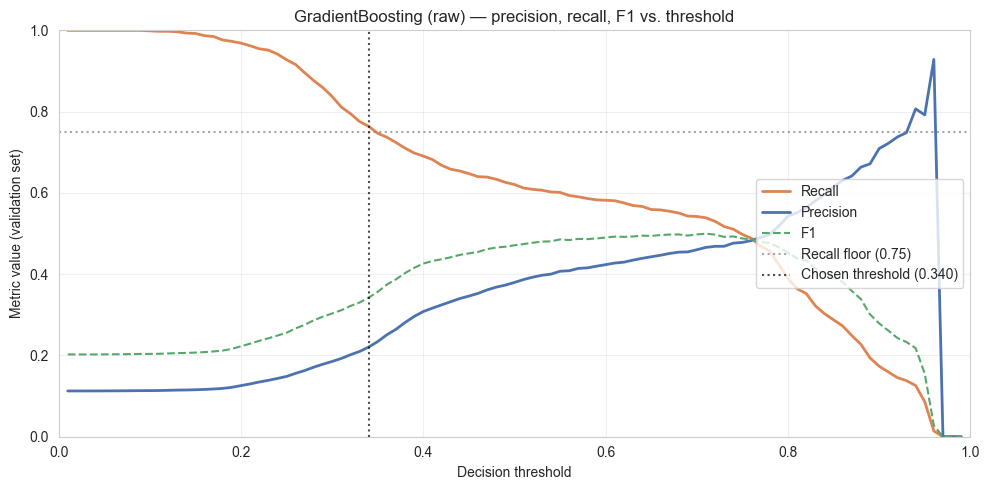

In [15]:
w = chosen_results[WINNER]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(w["sweep"], w["rec_sweep"],  color="#DD8452", linewidth=2, label="Recall")
ax.plot(w["sweep"], w["prec_sweep"], color="#4C72B0", linewidth=2, label="Precision")
ax.plot(w["sweep"], w["f1_sweep"],   color="#55A868", linewidth=1.5, linestyle="--", label="F1")
ax.axhline(0.75, color="gray",  linestyle=":", alpha=0.7, label="Recall floor (0.75)")
ax.axvline(chosen_threshold, color="black", linestyle=":", alpha=0.7,
           label=f"Chosen threshold ({chosen_threshold:.3f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value (validation set)")
ax.set_title(f"{WINNER} ({'calibrated' if USE_CALIBRATED else 'raw'}) — precision, recall, F1 vs. threshold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
def evaluate(name, X, y, pipe, threshold):
    proba = pipe.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    metrics = {
        "split": name,
        "auc":       roc_auc_score(y, proba),
        "f1":        f1_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall":    recall_score(y, pred),
    }
    print(f"{name:5s} | AUC={metrics['auc']:.4f}  F1={metrics['f1']:.4f}  "
          f"P={metrics['precision']:.4f}  R={metrics['recall']:.4f}")
    return metrics

train_m = evaluate("train", X_train, y_train, pipeline, chosen_threshold)
val_m   = evaluate("val",   X_val,   y_val,   pipeline, chosen_threshold)
test_m  = evaluate("test",  X_test,  y_test,  pipeline, chosen_threshold)

train | AUC=0.8633  F1=0.3906  P=0.2526  R=0.8606
val   | AUC=0.8057  F1=0.3423  P=0.2206  R=0.7640
test  | AUC=0.8136  F1=0.3558  P=0.2296  R=0.7899


In [17]:
import json
from pathlib import Path

baseline = {
    "n_train":     int(len(X_train)),
    "numeric":     {},
    "categorical": {},
}

for c in numeric_cols:
    s = X_train[c]
    baseline["numeric"][c] = {
        "mean":      float(s.mean()),
        "std":       float(s.std()),
        "p10":       float(s.quantile(0.10)),
        "p50":       float(s.quantile(0.50)),
        "p90":       float(s.quantile(0.90)),
        "min":       float(s.min()),
        "max":       float(s.max()),
        "bin_edges": np.linspace(s.min(), s.max(), 11).tolist(),
    }

for c in categorical_cols:
    counts = X_train[c].value_counts(normalize=True).to_dict()
    baseline["categorical"][c] = {k: float(v) for k, v in counts.items()}

BASELINE_PATH = Path.cwd() / "train_reference_stats.json"
BASELINE_PATH.write_text(json.dumps(baseline, indent=2), encoding="utf-8")
print(f"Wrote baseline: {BASELINE_PATH}  ({BASELINE_PATH.stat().st_size} bytes)")
print(f"Numeric features tracked:     {len(baseline['numeric'])}")
print(f"Categorical features tracked: {len(baseline['categorical'])}")

Wrote baseline: c:\Users\PcUser\Desktop\drift-triage-copilot\mlops\train_reference_stats.json  (6795 bytes)
Numeric features tracked:     10
Categorical features tracked: 10


In [18]:
import hashlib, platform, sys
from datetime import datetime, timezone
import joblib, sklearn, numpy, pandas, mlflow

ARTIFACT_PATH = Path.cwd() / "bank_marketing_classifier.joblib"
joblib.dump(pipeline, ARTIFACT_PATH)
print(f"Saved artifact: {ARTIFACT_PATH}  ({ARTIFACT_PATH.stat().st_size} bytes)")

def sha256_of(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(64 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

artifact_hash = sha256_of(ARTIFACT_PATH)
print(f"SHA-256: {artifact_hash}")
print(f"Short:   {artifact_hash[:12]}")

env_meta = {
    "python":      sys.version.split()[0],
    "platform":    platform.platform(),
    "sklearn":     sklearn.__version__,
    "numpy":       numpy.__version__,
    "pandas":      pandas.__version__,
    "mlflow":      mlflow.__version__,
    "captured_at": datetime.now(timezone.utc).isoformat(),
}
print("\nEnvironment fingerprint:")
print(json.dumps(env_meta, indent=2))

Saved artifact: c:\Users\PcUser\Desktop\drift-triage-copilot\mlops\bank_marketing_classifier.joblib  (180057 bytes)
SHA-256: 20afcf1b003f9434a7fafc2165ef84391701aa8441aaf28c304d5e8510190ea4
Short:   20afcf1b003f

Environment fingerprint:
{
  "python": "3.12.13",
  "platform": "Windows-11-10.0.26200-SP0",
  "sklearn": "1.8.0",
  "numpy": "2.4.4",
  "pandas": "2.3.3",
  "mlflow": "3.11.1",
  "captured_at": "2026-05-06T18:35:39.592801+00:00"
}


In [19]:
MODEL_NAME          = "bank-marketing-classifier"
MODEL_VERSION_LABEL = "v0.1.0-week5"

card = f"""# Model Card — {MODEL_NAME} ({MODEL_VERSION_LABEL})

## Intended use
Predict whether a Portuguese retail bank customer will subscribe to a term
deposit, given pre-call customer attributes, prior-campaign history, and the
macroeconomic context at the time of the call. Used to prioritize outbound
calling lists.

## Training data
UCI Bank Marketing (`bank-additional-full.csv`), 41,188 rows, ~11.27% positive.
Stratified 60/20/20 train/val/test split, `random_state=42`.
Engineered features: dropped `duration` (target leakage); split `pdays` into
`was_contacted_before` (flag) + `days_since_contact` (numeric).

## Architecture
Single sklearn `Pipeline`:
- `ColumnTransformer`: `StandardScaler` on {len(numeric_cols)} numeric columns,
  `OneHotEncoder(handle_unknown='ignore')` on {len(categorical_cols)} categorical columns.
- Classifier: {WINNER}{' (sigmoid-calibrated, cv=10)' if USE_CALIBRATED else ''},
  `class_weight='balanced'`, `random_state=42`.
- 63 features after preprocessing.

## Operating threshold
{chosen_threshold:.3f} — chosen on validation as the highest threshold meeting
recall ≥ 0.75 (week 5 day 2 rule). Stored separately from the pipeline as a
serving-side configuration value.

## Metrics
| Split | AUC | F1 | Precision | Recall |
|-------|-----|----|-----------|--------|
| Train | {train_m['auc']:.4f} | {train_m['f1']:.4f} | {train_m['precision']:.4f} | {train_m['recall']:.4f} |
| Val   | {val_m['auc']:.4f}   | {val_m['f1']:.4f}   | {val_m['precision']:.4f}   | {val_m['recall']:.4f} |
| Test  | {test_m['auc']:.4f}  | {test_m['f1']:.4f}  | {test_m['precision']:.4f}  | {test_m['recall']:.4f} |

## Known limits
- Class imbalance (~11% positive). Threshold-sensitive — default 0.5 is wrong for this model.
- `default=yes` has only n=3 in training; that one-hot column is effectively unused.
- `month` reflects the bank's calling-strategy volume-vs-quality trade-off, not pure seasonality.
- Macroeconomic features span the 2008 financial crisis; behavior under future regime shifts is uncertain.
- No drift detection inside the model itself; drift is monitored externally over a rolling window.

## Artifact
- SHA-256: `{artifact_hash}`
- File:    `{ARTIFACT_PATH.name}` ({ARTIFACT_PATH.stat().st_size} bytes)

## Environment fingerprint
```json
{json.dumps(env_meta, indent=2)}
```
"""

MODEL_CARD_PATH = Path.cwd() / "model_card.md"
MODEL_CARD_PATH.write_text(card, encoding="utf-8")
print(f"Wrote model card: {MODEL_CARD_PATH}  ({MODEL_CARD_PATH.stat().st_size} bytes)")

Wrote model card: c:\Users\PcUser\Desktop\drift-triage-copilot\mlops\model_card.md  (2310 bytes)


In [20]:
from mlflow.models.signature import infer_signature

signature     = infer_signature(X_train, pipeline.predict(X_train))
input_example = X_train.head(2)

with mlflow.start_run(run_name=f"{MODEL_NAME}-{MODEL_VERSION_LABEL}") as run:
    for split, m in [("train", train_m), ("val", val_m), ("test", test_m)]:
        for key in ("auc", "f1", "precision", "recall"):
            mlflow.log_metric(f"{split}_{key}", m[key])

    mlflow.log_param("classifier",          WINNER)
    mlflow.log_param("calibrated",          USE_CALIBRATED)
    mlflow.log_param("operating_threshold", chosen_threshold)
    mlflow.log_param("n_features",          63)
    mlflow.log_param("random_state",        42)

    for k, v in env_meta.items():
        mlflow.set_tag(f"env.{k}", v)
    mlflow.set_tag("artifact.sha256",   artifact_hash)
    mlflow.set_tag("artifact.filename", ARTIFACT_PATH.name)

    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name=MODEL_NAME,
    )

    mlflow.log_artifact(str(MODEL_CARD_PATH), artifact_path="docs")
    mlflow.log_artifact(str(BASELINE_PATH),   artifact_path="reference")

    RUN_ID = run.info.run_id

print(f"Run logged: {RUN_ID}")
print(f"Registered model: {MODEL_NAME}")
print(f"Operating threshold (kept separately as a serving config): {chosen_threshold}")

c:\Users\PcUser\Desktop\drift-triage-copilot\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/06 21:35:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 21:35:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requi

Run logged: a01ddecbab094010a63661a5ed78eed8
Registered model: bank-marketing-classifier
Operating threshold (kept separately as a serving config): 0.34


Registered model 'bank-marketing-classifier' already exists. Creating a new version of this model...
Created version '6' of model 'bank-marketing-classifier'.
